# 0 - ADSR Predictor

Test to build a single model that could handle ADSR envelope prediction with note prediction. Results show that note prediction is good but ADSR is still very weak.

In [1]:
import sys
sys.path.insert(0, "..")

import os
os.environ["PYTORCH_HIP_ALLOC_CONF"] = "garbage_collection_threshold:0.8"

from pathlib import Path
import random

from IPython.display import Audio, display
from tqdm import tqdm
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import mlflow

from rustic_ml.encoding import encode_adsr, decode_adsr, NOTE_MIN, NOTE_MAX, N_NOTES
from rustic_ml.dataset import random_spec, render_mel, generate_dataset, NpzDataset
from rustic_ml.analysis import MetricSpec, analyze_run
from rustic_ml.evaluation import accumulate_inference, plot_accuracy, compare_audio
from rustic_ml.mlflow_ui import show_register_widget, show_describe_widget, show_registered_models
from rustic_ml.training import set_seeds, log_hyperparams, compute_and_log_metrics
from rustic_ml.comparison import compare_models
from rustic_py.rustic_py import render

In [2]:
if torch.cuda.is_available():
    device = "cuda"
    print("CUDA detected, Using device cuda")
elif torch.backends.mps.is_available():
    device = "mps"
    print("Using MPS")
else:
    device = "cpu"
    print("No device detected, using CPU")

device = torch.device(device)

No device detected, using CPU


In [3]:
print(f"Using torch {torch.__version__} device {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")
print(f"HIP version: {torch.version.hip}")
print(f"Using mlflow {mlflow.__version__}")
print(f"Rustic_ML OK - notes [{NOTE_MIN}, {NOTE_MAX}] N_NOTES={N_NOTES}")

Using torch 2.5.1+cu121 device cpu
HIP version: None
Using mlflow 3.10.1
Rustic_ML OK - notes [36, 84] N_NOTES=49


## Hyperparameters & paths

In [5]:
# MlFlow
MLFLOW_URI = "http://192.168.1.254:5000"
MLFLOW_EXPERIMENT = "ADSRPredictor"

# Dataset
DATA_DIR = Path("/data/datasets")
BATCH_SIZE_GEN = 1_000

# Training parameters
HYPER = {
    "seed":        42,
    "n_samples":   80_000,
    "batch_size":  64,
    "n_epochs":    80,
    "lr":          1e-3,
    "lambda_adsr": 1e-5,
}
set_seeds(HYPER["seed"])

## Datasets generation or loading

In [6]:
files = list(DATA_DIR.glob("*.npz"))
total = sum(np.load(p)["note"].shape[0] for p in DATA_DIR.glob("*.npz"))
print(f"Found {len(files)} dataset files ({total} total samples)")
if total < N_SAMPLES:
    missing = N_SAMPLES - total
    print(f"Missing {missing} samples, generating...")
    generate_dataset(
        missing,
        DATA_DIR,
        batch_size=BATCH_SIZE_GEN,
        waveform="sine",
        start_batch=len(files),
        n_workers=8
    )

Found 60 dataset files (60000 total samples)
Missing 20000 samples, generating...


In [7]:
all_files = random.sample(sorted(DATA_DIR.glob("*.npz")), round(N_SAMPLES / BATCH_SIZE_GEN))
print(f"Selecting {round(N_SAMPLES / BATCH_SIZE_GEN)} files for ~{N_SAMPLES} samples")
split = int(0.8 * len(all_files))

train_ds = NpzDataset(all_files[:split])
val_ds   = NpzDataset(all_files[split:])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)} samples  Val: {len(val_ds)} samples")

Selecting 80 files for ~80000 samples
Train: 64000 samples  Val: 16000 samples


## Model

In [8]:
class ADSRPredictor(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, None))
        self.note_head = nn.Linear(128 * 5, N_NOTES)
        self.adsr_head = nn.Linear(128 * 5, 4)
        self.dropout = nn.Dropout(0.3)

    def forward(self, mel) -> tuple:
        x = self.conv1(mel)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.pool(x)
        x = x.flatten(start_dim=1)
        x = self.dropout(x)

        adsr_raw = self.adsr_head(x)
        adsr_out = adsr_raw.clone()
        adsr_out[:, 2] = torch.sigmoid(adsr_raw[:, 2])
        return self.note_head(x), adsr_out

In [9]:
model = ADSRPredictor().to(device)

criterion_note = nn.CrossEntropyLoss()
criterion_adsr = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print("Model moved to device")
print(torch.cuda.memory_allocated() / 1e6, "MB allocated")
print(torch.cuda.memory_reserved() / 1e6, "MB reserved")

Model moved to device
0.537088 MB allocated
2.097152 MB reserved


## Training

In [10]:
print(f"Connecting to MLFlow on {MLFLOW_URI}")
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

Connecting to MLFlow on http://192.168.1.254:5000


<Experiment: artifact_location='/data/artifacts/1', creation_time=1773911017921, experiment_id='1', last_update_time=1773911017921, lifecycle_stage='active', name='ADSRPredictor', tags={}, workspace='default'>

2026/03/22 15:07:52 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

Epoch: 100%|██████████| 80/80 [1:06:58<00:00, 50.23s/it]


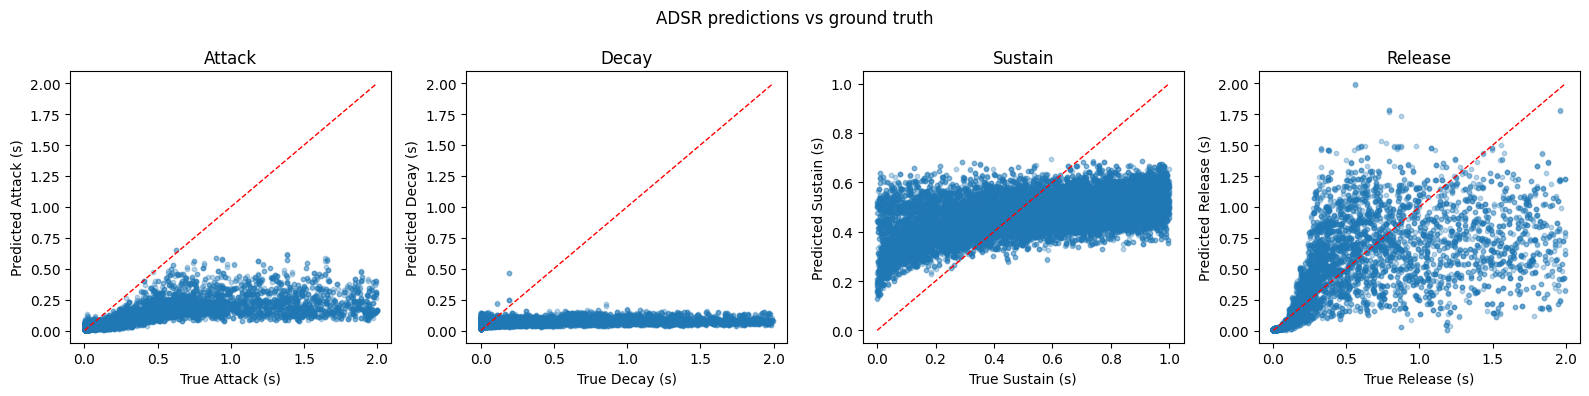

Note accuracy: 1.000


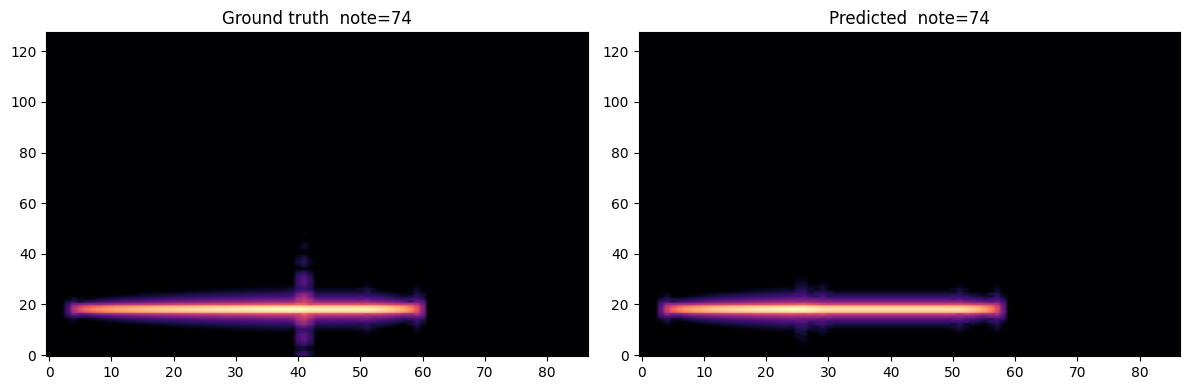

Ground truth — note=74  A=0.426 D=0.004 S=0.780 R=0.093


Predicted    — note=74  A=0.251 D=0.040 S=0.592 R=0.068


2026/03/22 16:14:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 16:15:00 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/22 16:15:00 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/22 16:15:03 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). ML

🏃 View run lyrical-crane-943 at: http://192.168.1.254:5000/#/experiments/1/runs/178c5467f90643e08c298d07001e09db
🧪 View experiment at: http://192.168.1.254:5000/#/experiments/1


In [12]:
def train_model(mode, optimizer, train_loader, val_loader, device, hyper) -> dict:
    with mlflow.start_run() as run:
        RUN_ID = run.info.run_id        
        log_hyperparams(hyper)
    
        for epoch in tqdm(range(N_EPOCHS), desc=f"Epoch"):
            # Train
            model.train()
            train_losses = {"loss": 0.0, "note": 0.0, "adsr": 0.0}
            for mel, note, adsr in train_loader:
                mel, note, adsr = mel.to(device), note.to(device), adsr.to(device)
    
                optimizer.zero_grad()
                note_logits, adsr_pred = model(mel)
    
                loss_note = criterion_note(note_logits, note - NOTE_MIN)
                loss_adsr = criterion_adsr(adsr_pred, adsr)
                loss = loss_note + LAMBDA_ADSR * loss_adsr
    
                train_losses["loss"] += loss.item()
                train_losses["note"] += loss_note.item()
                train_losses["adsr"] += loss_adsr.item()
    
                loss.backward()
                optimizer.step()
    
            # Eval
            model.eval()
            val_losses = {"loss": 0.0, "note": 0.0, "adsr": 0.0}
            val_accuracy_dict = {"correct": 0, "total": 0}
            with torch.no_grad():
                for mel, note, adsr in val_loader:
                    mel, note, adsr = mel.to(device), note.to(device), adsr.to(device)
    
                    note_logits, adsr_pred = model(mel)
                    
                    val_accuracy_dict["correct"] += (note_logits.argmax(dim=1) == note - NOTE_MIN).sum().item()
                    val_accuracy_dict["total"]   += note.size(0)
    
                    loss_note = criterion_note(note_logits, note - NOTE_MIN)
                    loss_adsr = criterion_adsr(adsr_pred, adsr)
                    loss = loss_note + LAMBDA_ADSR * loss_adsr
    
                    val_losses["loss"] += loss.item()
                    val_losses["note"] += loss_note.item()
                    val_losses["adsr"] += loss_adsr.item()
    
            compute_and_log_metrics(
                train_losses, len(train_loader),
                val_losses, len(val_loader),
                val_accuracy_dict["correct"] / val_accuracy_dict["total"],
                epoch,
            )
    
        # Accumulation loop for model evaluation
        vals = accumulate_inference(model, val_loader, device)
    
        # Plot accuracy
        plot_accuracy(vals)
    
        # Audio comparison
        compare_audio(model, val_ds, device)
    
        # Log the model
        mlflow.pytorch.log_model(model, "model")

## Post-training analysis

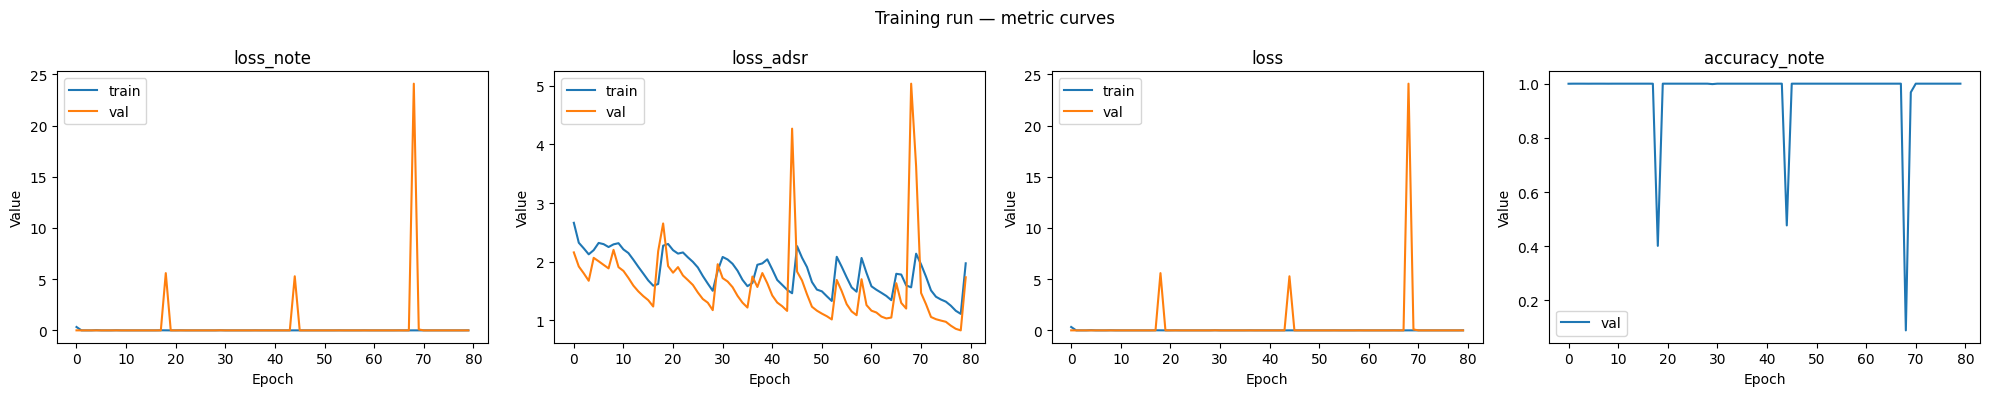

[STILL LEARNING] train/loss_adsr slope over last 20% of epochs = -0.02478 — training should continue (try n_epochs=159)
[LOSS IMBALANCE] train/loss_note=0.0043 << train/loss_adsr=1.9727 (ratio=0.0022) — ADSR loss dominates gradient updates; try decreasing LAMBDA_ADSR to rebalance (try lambda_adsr=0.0)


In [13]:
METRICS = [
    MetricSpec("train/loss_note",   "train", "loss_note"),
    MetricSpec("val/loss_note",     "val",   "loss_note"),
    MetricSpec("train/loss_adsr",   "train", "loss_adsr"),
    MetricSpec("val/loss_adsr",     "val",   "loss_adsr"),
    MetricSpec("train/loss",        "train", "loss"),
    MetricSpec("val/loss",          "val",   "loss"),
    MetricSpec("val/accuracy_note", "val",   "accuracy_note"),
]

analyze_run(METRICS, run_id=RUN_ID, tracking_uri=MLFLOW_URI)

In [14]:
show_register_widget(RUN_ID, tracking_uri=MLFLOW_URI)
show_describe_widget(RUN_ID, tracking_uri=MLFLOW_URI)

Output()

Output()

In [15]:
def show_registered_models(tracking_uri: str | None = None) -> None:
      """Print a summary table of all registered models and their versions.

      For each model shows: name, latest version number, creation time,
      and any aliases assigned to each version.

      Args:
          tracking_uri: MLflow tracking server URI. Uses the active URI if None.
      """
      import mlflow
      from mlflow.tracking import MlflowClient

      if tracking_uri is not None:
          mlflow.set_tracking_uri(tracking_uri)

      client = MlflowClient()
      models = client.search_registered_models()

      if not models:
          print("No registered models found.")
          return

      for rm in models:
          versions = client.search_model_versions(f"name='{rm.name}'")
          if not versions:
              print(f"{rm.name}  (no versions)")
              continue

          latest = max(versions, key=lambda v: int(v.version))
          print(f"\n{rm.name}  —  {len(versions)} version(s), latest: v{latest.version}")
          print(f"  {'Ver':<6} {'Run ID':<36} {'Aliases'}")
          print(f"  {'-'*6} {'-'*36} {'-'*20}")
          for v in sorted(versions, key=lambda v: int(v.version), reverse=True):
              aliases = ", ".join(v.aliases) if v.aliases else "-"
              print(f"  v{v.version:<5} {v.run_id}  {aliases}")

In [16]:
def compare_to_previous_model(
    model_name: str,
    current_model: nn.Module = model,
    loader: DataLoader = val_loader,
    MLFLOW_URI=MLFLOW_URI
) -> None:
    """Compare the freshly trained model against the latest registered version.
    
    Loads the latest registered version from the MLflow Model Registry,
    runs both models on `loader`, prints a side-by-side metric table,
    and renders ADSR scatter plots for both so you can decide whether to
    register the new model.
    
    Args:
      model_name:    Registered model name in the MLflow registry.
      current_model: The freshly trained in-memory model.
      loader:        Validation DataLoader yielding (mel, note, adsr) batches.
    """
    from mlflow.tracking import MlflowClient
    import mlflow.pytorch
    
    mlflow.set_tracking_uri(MLFLOW_URI)
    client = MlflowClient()
    
    # --- Fetch latest registered version ---
    try:
        versions = client.search_model_versions(f"name='{model_name}'")
    except Exception:
        versions = []
    
    if not versions:
        print(f"No registered model '{model_name}' found — nothing to compare against.")
        print("Model list:")
        show_registered_models()
        return
    
    latest = max(versions, key=lambda v: int(v.version))
    prev_uri = f"models:/{model_name}/{latest.version}"
    print(f"Loading '{model_name}' v{latest.version} from {prev_uri} ...")
    prev_model = mlflow.pytorch.load_model(prev_uri, map_location=device)
    prev_model.to(device).eval()
    
    # --- Run inference on both ---
    print("Accumulating inference on validation set ...")
    curr_vals = accumulate_inference(current_model, loader, device)
    prev_vals = accumulate_inference(prev_model,    loader, device)
    
    # --- Compute summary metrics ---
    def _metrics(vals: dict) -> dict:
        note_acc = float((vals["note"]["preds"] == vals["note"]["targets"]).mean())
        per_param = np.abs(vals["adsr"]["preds_s"] - vals["adsr"]["targets_s"])  # (4, N)
        return {
            "note_acc": note_acc,
            "adsr_mae": float(per_param.mean()),
            "Attack":   float(per_param[0].mean()),
            "Decay":    float(per_param[1].mean()),
            "Sustain":  float(per_param[2].mean()),
            "Release":  float(per_param[3].mean()),
        }
    
    prev_m = _metrics(prev_vals)
    curr_m = _metrics(curr_vals)
    
    # --- Comparison table ---
    rows = [
        ("note_acc", "Note accuracy",    True),   # higher is better
        ("adsr_mae", "ADSR MAE (s)",     False),
        ("Attack",   "  Attack MAE (s)", False),
        ("Decay",    "  Decay MAE (s)",  False),
        ("Sustain",  "  Sustain MAE",    False),
        ("Release",  "  Release MAE (s)",False),
    ]
    header = f"{'Metric':<22}  {'Prev (v'+str(latest.version)+')':<18}  {'Current':<18}  {'Delta':>10}  Win"
    print(f"\n{header}")
    print("-" * len(header))
    current_wins = 0
    for key, label, higher_better in rows:
        p, c = prev_m[key], curr_m[key]
        delta = c - p
        win = (delta > 0) == higher_better
        if delta == 0:
            marker = "="
        elif win:
            marker = "NEW"
            current_wins += 1
        else:
            marker = "OLD"
        sign = "+" if delta >= 0 else ""
        print(f"  {label:<20}  {p:<18.4f}  {c:<18.4f}  {sign}{delta:>8.4f}  {marker}")
    
    total = sum(1 for *_, _ in rows)
    print(f"\nCurrent model wins {current_wins}/{total} metrics vs v{latest.version}.")
    
    # --- ADSR scatter plots: previous (top) vs current (bottom) ---
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    param_labels = ["Attack", "Decay", "Sustain", "Release"]
    for row_idx, (vals, title) in enumerate([
        (prev_vals, f"Previous v{latest.version}"),
        (curr_vals, "Current (this run)"),
    ]):
        for col, label in enumerate(param_labels):
            ax = axes[row_idx][col]
            t = vals["adsr"]["targets_s"][col]
            p = vals["adsr"]["preds_s"][col]
            ax.scatter(t, p, alpha=0.2, s=8)
            lo, hi = float(t.min()), float(t.max())
            ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
            ax.set_title(f"{title} — {label}")
            ax.set_xlabel("True (s)")
            ax.set_ylabel("Pred (s)")
    
    plt.suptitle(f"ADSR scatter: '{model_name}' v{latest.version} vs current", fontsize=13)
    plt.tight_layout()
    plt.show()

Loading 'ADSR predictor' v3 from models:/ADSR predictor/3 ...
Accumulating inference on validation set ...

Metric                  Prev (v3)           Current                  Delta  Win
-------------------------------------------------------------------------------
  Note accuracy         1.0000              1.0000              +  0.0000  =
  ADSR MAE (s)          0.1690              0.1958              +  0.0268  OLD
    Attack MAE (s)      0.1282              0.2035              +  0.0753  OLD
    Decay MAE (s)       0.2222              0.2399              +  0.0177  OLD
    Sustain MAE         0.2028              0.2134              +  0.0106  OLD
    Release MAE (s)     0.1229              0.1265              +  0.0036  OLD

Current model wins 0/6 metrics vs v3.


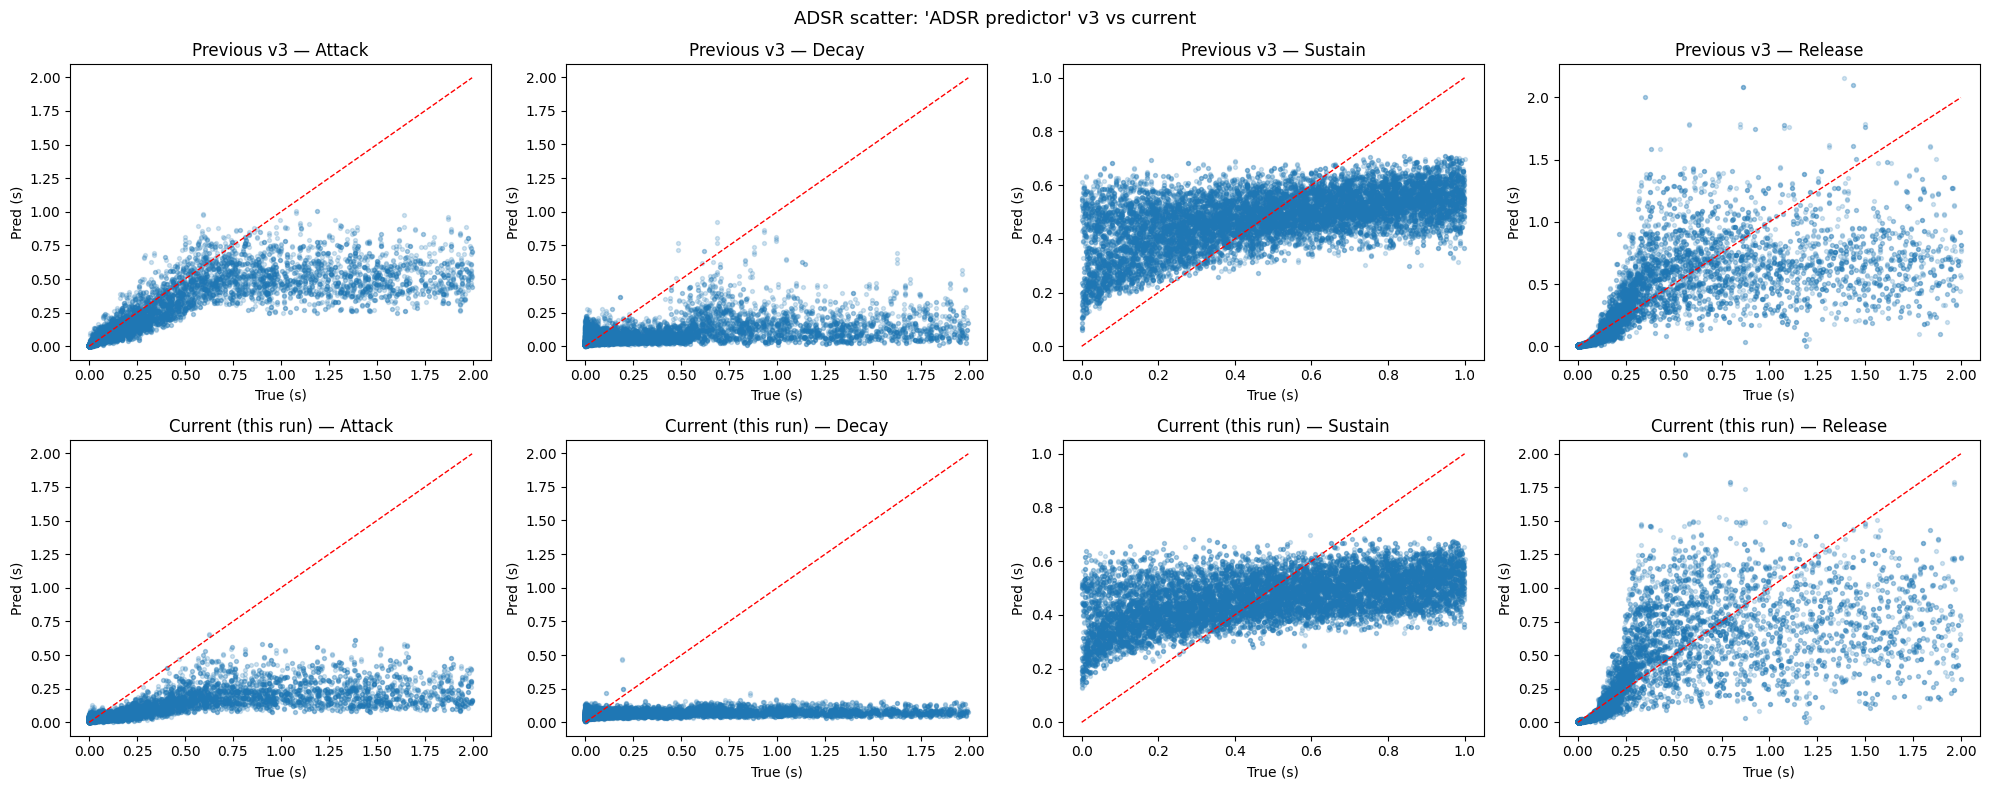

In [17]:
compare_to_previous_model("ADSR predictor", current_model=model)